Let's do some image classication using bayesian convolkutionary neural networks!

Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 52ms/step - accuracy: 0.1737 - loss: 4.4145 - val_accuracy: 0.2914 - val_loss: 2.4272
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.2468 - loss: 2.7865 - val_accuracy: 0.3432 - val_loss: 2.1187
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.2692 - loss: 2.4875 - val_accuracy: 0.3626 - val_loss: 1.9997
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.2990 - loss: 2.2786 - val_accuracy: 0.3864 - val_loss: 1.8513
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.3215 - loss: 2.1344 - val_accuracy: 0.3988 - val_loss: 1.7722
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.3460 - loss: 2.0331 - val_accuracy: 0.4274 - val_loss: 1.7136
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.3469 - loss: 1.9815 - val_accuracy: 0.4490 - val_loss: 1.6054
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.3627 - loss: 1.91

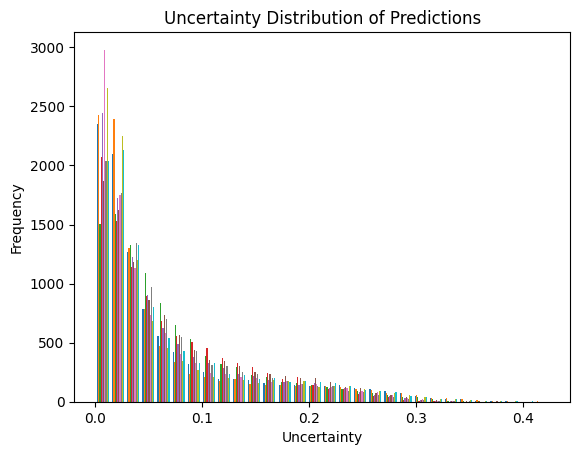

In [24]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Load and preprocess CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train.astype('float32') / 255.0, x_test.astype('float32') / 255.0
y_train, y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)

# Split dataset into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

# Data augmentation
datagen = ImageDataGenerator(
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, rotation_range=10, zoom_range=0.1
)
datagen.fit(x_train)

# Define a modified Bayesian CNN model
class SimplifiedBayesianCNN(tf.keras.Model):
    def __init__(self):
        super(SimplifiedBayesianCNN, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
        
        self.conv2 = tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu')
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.pool2 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
        
        self.conv3 = tf.keras.layers.Conv2D(128, kernel_size=3, activation='relu')
        self.bn3 = tf.keras.layers.BatchNormalization()
        self.pool3 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
        
        self.flatten = tf.keras.layers.Flatten()
        self.dense1 = tfp.layers.DenseFlipout(128, activation='relu')
        self.dropout = tf.keras.layers.Dropout(0.4)
        self.output_layer = tfp.layers.DenseFlipout(10, activation='softmax')

    def call(self, inputs, training=False):
        x = self.pool1(self.bn1(self.conv1(inputs), training=training))
        x = self.pool2(self.bn2(self.conv2(x), training=training))
        x = self.pool3(self.bn3(self.conv3(x), training=training))
        x = self.flatten(x)
        x = self.dense1(x)
        if training:
            x = self.dropout(x, training=training)
        return self.output_layer(x)

# Instantiate and compile the model with a learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
model = SimplifiedBayesianCNN()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train the model using data augmentation
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_val, y_val)
)

# Function for Monte Carlo sampling to estimate uncertainty
def predict_with_uncertainty(model, x, n_iter=10):
    predictions = np.array([model(x, training=True) for _ in range(n_iter)])
    return predictions.mean(axis=0), predictions.std(axis=0)

# Evaluate on test set
mean_preds, uncertainty = predict_with_uncertainty(model, x_test)
test_accuracy = np.mean(np.argmax(mean_preds, axis=1) == np.argmax(y_test, axis=1))

print(f"Test Accuracy: {test_accuracy:.2f}")
plt.hist(uncertainty, bins=30)
plt.title('Uncertainty Distribution of Predictions')
plt.xlabel('Uncertainty')
plt.ylabel('Frequency')
plt.show()
